In [96]:
import sys, os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))

from src import db

In [97]:
# Garantir que o src seja importável
PROJECT_ROOT = Path.cwd().resolve().parent

sys.path.insert(0, str(PROJECT_ROOT))

In [98]:
#conferir o seu diretório de trabalho atual
os.getcwd()


'c:\\Users\\carva\\central_eto\\notebooks'

In [99]:
# Testando o ambiente, estamos mesmo usando o python do ambiente virtual?
sys.executable

'c:\\Users\\carva\\central_eto\\.venv\\Scripts\\python.exe'

In [100]:
db.test_connection()

(1,)

## Data Pofiling 
- Janela temporal? min e max -> definicao janela 
- Volume pedidos?
- Quantidade de clientes?

In [101]:
from pathlib import Path
import re

# ler arquivo
sql_text = Path("../queries/profiling.sql").read_text()

# separar queries pelo marcador
queries = re.split(r"-- QUERIE:", sql_text)[1:]

# executar
results = {}

for q in queries:
    name, sql = q.strip().split("\n", 1)
    results[name.strip()] = db.get_data(sql)

# ver nomes disponíveis
print(results.keys())



c:\Users\carva\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


dict_keys(['CLIENTES DESDE 2023', 'DATA MIN MAX', 'VOLUME POR ANO'])


In [102]:
results["VOLUME POR ANO"]

,ANO,QTD
0,2007,40
1,2008,3521
2,2009,12109
3,2010,16648
4,2011,16299
5,2012,5558
6,2013,1
7,2018,8
8,2021,47192
9,2022,66612


In [103]:
results["CLIENTES DESDE 2023"]

,clientes
0,743


In [104]:
results["DATA MIN MAX"]

,DATA_MIN,DATA_MAX,QTD
0,2007-03-29,2026-03-04,494719


In [105]:
sql = Path("../queries/base.sql").read_text()
df_base = db.get_data(sql)

df_base.head()

c:\Users\carva\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


,CLIENTE,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED
0,903,CME,2024-07-06,17.28,0119925
1,37,GUSTAVO AQUINO,2021-05-03,24.25,25026
2,37,GUSTAVO AQUINO,2021-05-03,0.00,25026
3,37,GUSTAVO AQUINO,2021-05-03,25.84,25026
4,2,SME,2021-05-03,7.21,52


In [106]:
df_base["DATA_ENTRADA"] = pd.to_datetime(df_base["DATA_ENTRADA"], errors="coerce")
df_base["ANO_MES"] = df_base["DATA_ENTRADA"].dt.to_period("M")
df_base.head()

,CLIENTE,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED,ANO_MES
0,903,CME,2024-07-06,17.28,0119925,2024-07
1,37,GUSTAVO AQUINO,2021-05-03,24.25,25026,2021-05
2,37,GUSTAVO AQUINO,2021-05-03,0.00,25026,2021-05
3,37,GUSTAVO AQUINO,2021-05-03,25.84,25026,2021-05
4,2,SME,2021-05-03,7.21,52,2021-05


In [107]:
df_base.shape

(494719, 6)

In [108]:
df_base["DATA_ENTRADA"] = pd.to_datetime(df_base["DATA_ENTRADA"], errors="coerce")
df_base["ANO_MES"] = df_base["DATA_ENTRADA"].dt.to_period("M").info()


<class 'pandas.Series'>
RangeIndex: 494719 entries, 0 to 494718
Series name: DATA_ENTRADA
Non-Null Count   Dtype    
--------------   -----    
494719 non-null  period[M]
dtypes: period[M](1)
memory usage: 3.8 MB


Triagem de tipos. cliente e nro_ped sao identificadores. transormar em str 

## Check de sanidade - qualidade dos dados

In [109]:
sys.path.append("..")   
from src.sanity_check import sanity_check

sanity_check(
    df_base,
    value_col="VL_SERVICO",
    date_col="DATA_ENTRADA",    
    id_cols=["CLIENTE", "NRO_PED"]  )  

Shape: (494719, 6)

Missing:
CLIENTE              0
SETOR                0
DATA_ENTRADA         0
VL_SERVICO           0
NRO_PED              0
ANO_MES         494719
dtype: int64

Duplicados:
69346

Negativos em VL_SERVICO : 49

Datas: 2007-03-29 00:00:00 2026-03-04 00:00:00

Duplicados por chave:
370022


In [110]:
df_base.loc[
    df_base["VL_SERVICO"] < 0,
    ["CLIENTE", "NRO_PED", "DATA_ENTRADA", "VL_SERVICO"]
]

,CLIENTE,NRO_PED,DATA_ENTRADA,VL_SERVICO
3168,10,23354,2021-05-15,-27.39
3774,40,25614,2021-05-18,-10.76
14967,5,11249,2021-07-10,-21.30
28791,15,26776,2021-09-14,-309.99
31956,74,17534,2021-09-29,-9.20
32181,104,22495,2021-09-30,-17.72
36753,3,16676,2021-10-21,-5.46
43798,29,5561,2021-11-23,-12.29
48735,63,12624,2021-12-13,-1.97
50574,226,7536,2021-12-21,-96.80


In [111]:
df_base["ANO_MES"] = df_base["DATA_ENTRADA"].dt.to_period("M")
df_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 494719 entries, 0 to 494718
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   CLIENTE       494719 non-null  int64         
 1   SETOR         494719 non-null  str           
 2   DATA_ENTRADA  494719 non-null  datetime64[us]
 3   VL_SERVICO    494719 non-null  float64       
 4   NRO_PED       494719 non-null  str           
 5   ANO_MES       494719 non-null  period[M]     
dtypes: datetime64[us](1), float64(1), int64(1), period[M](1), str(2)
memory usage: 22.6 MB


In [112]:
sys.path.append("..")

from src.features import make_cliente_mes

In [113]:
cliente_mes = make_cliente_mes(df_base, inicio="2023-01-01", neg_policy="clip0")
cliente_mes.head()

,CLIENTE,ANO_MES,total_pedidos,total_valor,qtd_itens,qtd_itens_negativos,ticket_medio,itens_por_pedido
0,1,2023-01,117,31032.50,538,0,265.235043,4.598291
1,1,2023-02,72,12877.19,307,0,178.849861,4.263889
2,1,2023-03,82,18778.31,346,0,229.003780,4.219512
3,1,2023-04,87,18732.18,383,0,215.312414,4.402299
4,1,2023-05,84,16106.26,328,0,191.741190,3.904762


## Teste de sanidade


In [114]:
sys.path.append("..")

from src.sanity_check import sanity_check

sanity_check(
    cliente_mes,
    value_col="total_valor",
    date_col="ANO_MES",
    id_cols="CLIENTE"
)

Shape: (9280, 8)

Missing:
CLIENTE                0
ANO_MES                0
total_pedidos          0
total_valor            0
qtd_itens              0
qtd_itens_negativos    0
ticket_medio           0
itens_por_pedido       0
dtype: int64

Duplicados:
0

Negativos em total_valor : 0

Datas: 2023-01 2026-03

Duplicados por chave:
8537


## EDA Analitica 
- O que explica inadimplencia/comportamento cliente

In [115]:
## RELACOES CLIENTE-MES
cliente_mes["total_pedidos"].describe()

count    9280.000000
mean        9.712284
std        57.018445
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max      1605.000000
Name: total_pedidos, dtype: float64

Distribuiçao extremamente assimetrica
Heterogeneidade de cliente - ate 25% fazem um pedido por mes. - valores max e minimos muito discrepantes 
Necessidade de segmentaçao - 


In [116]:
def classificar_volume(x):
    if x <= 2:
        return "baixo"
    elif x <= 5:
        return "medio"
    else:
        return "alto"

cliente_mes["categoria_volume"] = cliente_mes["total_pedidos"].apply(classificar_volume)
cliente_mes["categoria_volume"].value_counts(normalize=True)

categoria_volume
baixo    0.576401
alto     0.226401
medio    0.197198
Name: proportion, dtype: float64

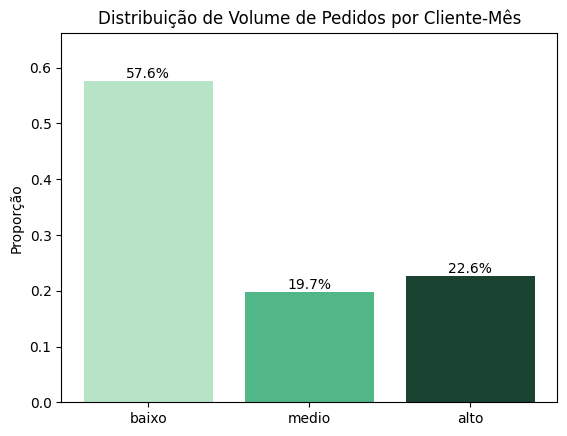

In [117]:
import matplotlib.pyplot as plt

# Ordem lógica (ordinal)
ordem = ["baixo", "medio", "alto"]

dist = (
    cliente_mes["categoria_volume"]
    .value_counts(normalize=True)
    .reindex(ordem)
)

plt.figure()

bars = plt.bar(
    dist.index,
    dist.values,
    color=["#b7e4c7", "#52b788", "#1b4332"]  # verde claro → escuro
)

plt.ylabel("Proporção")
plt.title("Distribuição de Volume de Pedidos por Cliente-Mês")

# Adicionando os percentuais
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(dist.values) * 1.15)
plt.xticks(rotation=0)
plt.show()

Cliente grande compra com qual frequência?
Cliente médio compra com qual frequência?
Cliente pequeno compra com qual frequência?
A classificação faz sentido?

In [124]:
# 1. TRATAMENTO DA DATA (O "pulo do gato")
# Tentamos converter de Period para Timestamp, se falhar, usamos o datetime comum.
try:
    if hasattr(cliente_mes["ANO_MES"], "dt"):
        cliente_mes["ANO_MES"] = cliente_mes["ANO_MES"].dt.to_timestamp()
    else:
        cliente_mes["ANO_MES"] = pd.to_datetime(cliente_mes["ANO_MES"])
except Exception:
    cliente_mes["ANO_MES"] = pd.to_datetime(cliente_mes["ANO_MES"])

# 2. SUA FUNÇÃO DE DIFERENÇA
def diff_meses(a, b):
    return (a.dt.year - b.dt.year) * 12 + (a.dt.month - b.dt.month)

# 3. CÁLCULO DO INTERVALO POR CLIENTE
# Criamos o deslocamento (shift) separado para evitar erros de alinhamento
mes_anterior = cliente_mes.groupby("CLIENTE")["ANO_MES"].shift(1)

cliente_mes["meses_desde_ultimo"] = diff_meses(cliente_mes["ANO_MES"], mes_anterior)

# 4. LIMPEZA FINAL
cliente_mes["meses_desde_ultimo"] = cliente_mes["meses_desde_ultimo"].fillna(0).astype(int)

# Visualize o resultado
print(cliente_mes.head(20))

    CLIENTE    ANO_MES  total_pedidos  total_valor  qtd_itens  \
0         1 2023-01-01            117     31032.50        538   
1         1 2023-02-01             72     12877.19        307   
2         1 2023-03-01             82     18778.31        346   
3         1 2023-04-01             87     18732.18        383   
4         1 2023-05-01             84     16106.26        328   
5         1 2023-06-01             80     15833.52        335   
6         1 2023-07-01            110     20592.80        433   
7         1 2023-08-01             77     14263.44        275   
8         1 2023-09-01             94     18925.77        393   
9         1 2023-10-01            109     21174.73        472   
10        1 2023-11-01             86     16606.99        404   
11        1 2023-12-01             85     23322.79        468   
12        1 2024-01-01             79     18633.30        397   
13        1 2024-02-01             55     12043.03        295   
14        1 2024-03-01   

In [125]:
cliente_mes.groupby("categoria_volume")["total_pedidos"].describe()

,count,mean,std,min,25%,50%,75%,max
categoria_volume,,,,,,,,
alto,2101.0,36.292242,115.959473,6.0,7.0,11.0,19.0,1605.0
baixo,5349.0,1.310525,0.462752,1.0,1.0,1.0,2.0,2.0
medio,1830.0,3.754098,0.771748,3.0,3.0,4.0,4.0,5.0


Nota-se que o cliente alto ainda é bem irregular, temos um grande desvio padrão.

## Criar analises mais intuitivas 
- resumir a história do cliente em métricas de fidelidade
- uma linha por cliente adicionando a métrica "saúde"
- Criar Red Flags
  - média e desvio padrão do intervalo
  - score recidiva, heatmap de comportamento
  - 

In [126]:
cliente_mes.groupby("categoria_volume")["meses_desde_ultimo"].describe()


,count,mean,std,min,25%,50%,75%,max
categoria_volume,,,,,,,,
alto,2101.0,0.988577,0.348962,0.0,1.0,1.0,1.0,11.0
baixo,5349.0,1.820153,2.569490,0.0,1.0,1.0,2.0,33.0
medio,1830.0,1.045902,0.562226,0.0,1.0,1.0,1.0,10.0


Os clientes pequenos sao mais variáveis.

In [ ]:
# Agrupando para entender o padrão de cada um
cliente_mes_fidelidade = cliente_mes.groupby("CLIENTE").agg(
    total_meses_ativos=("ANO_MES", "count"),
    intervalo_medio=("meses_desde_ultimo", lambda x: x[x > 0].mean()), # Média dos intervalos reais
    max_intervalo=("meses_desde_ultimo", "max"), # Maior tempo que ele já sumiu
    ultimo_pedido=("ANO_MES", "max")
).reset_index()

# Calculando há quanto tempo ele não aparece desde hoje (Recência)
hoje = cliente_mes["ANO_MES"].max()
cliente_mes_fidelidade["meses_sumido"] = (hoje.year - cliente_mes_fidelidade["ultimo_pedido"].dt.year) * 12 + \
                                     (hoje.month - cliente_mes_fidelidade["ultimo_pedido"].dt.month)

# Criando a Red Flag Dinâmica
# Se o tempo sumido for maior que a média dele + um "respiro", é Red Flag
cliente_mes_fidelidade["RED_FLAG"] = cliente_mes_fidelidade["meses_sumido"] > (cliente_mes_fidelidade["intervalo_medio"] + 1)
cliente_mes_fidelidade.head(20)

,CLIENTE,total_meses_ativos,intervalo_medio,max_intervalo,ultimo_pedido,meses_sumido,RED_FLAG
0,1,38,1.000000,1.0,2026-02-01,0,False
1,3,38,1.000000,1.0,2026-02-01,0,False
2,4,38,1.000000,1.0,2026-02-01,0,False
3,5,22,1.000000,1.0,2024-10-01,16,True
4,7,4,1.000000,1.0,2023-04-01,34,True
5,9,5,2.500000,3.0,2023-11-01,27,True
6,10,28,1.000000,1.0,2026-02-01,0,False
7,12,38,1.000000,1.0,2026-02-01,0,False
8,15,37,1.000000,1.0,2026-01-01,1,False
9,21,7,1.000000,1.0,2023-07-01,31,True


Qual o percentual de clientes que volta a comprar depois de 1 mes? 2meses? 3 meses? 
Validação de período determinado como churn.

In [127]:
cliente_mes.groupby("categoria_volume")["meses_desde_ultimo"].value_counts(normalize=True)

categoria_volume  meses_desde_ultimo
alto              1                     0.957163
                  0                     0.032842
                  2                     0.005712
                  3                     0.001904
                  4                     0.000952
                  11                    0.000476
                  6                     0.000476
                  5                     0.000476
baixo             1                     0.572070
                  2                     0.157226
                  0                     0.110675
                  3                     0.062068
                  4                     0.030099
                  5                     0.017573
                  6                     0.010469
                  7                     0.008226
                  8                     0.005609
                  9                     0.004300
                  11                    0.003365
                  12            

In [132]:
import sys
print(sys.executable)

c:\Users\carva\central_eto\.venv\Scripts\python.exe


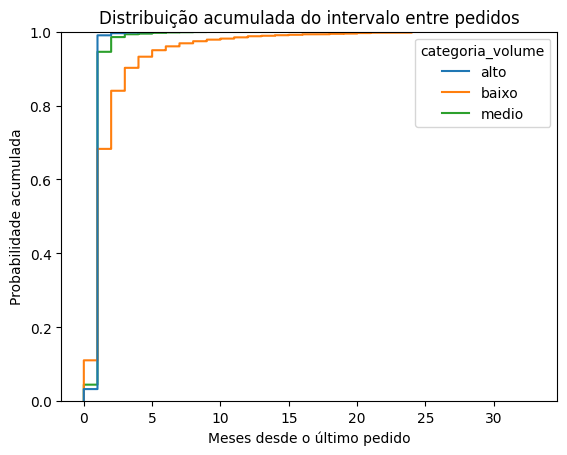

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.ecdfplot(
    data=cliente_mes,
    x="meses_desde_ultimo",
    hue="categoria_volume"
)

plt.title("Distribuição acumulada do intervalo entre pedidos")
plt.xlabel("Meses desde o último pedido")
plt.ylabel("Probabilidade acumulada")
plt.show()

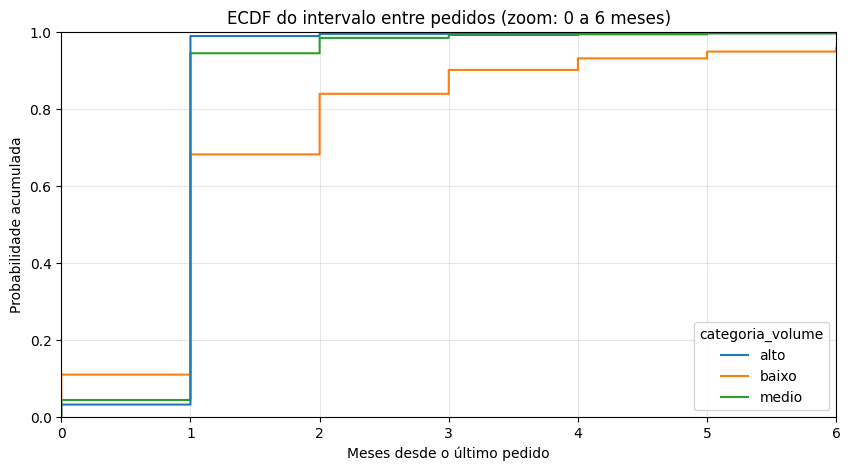

In [137]:
df_plot = cliente_mes.dropna(subset=["meses_desde_ultimo"]).copy()

plt.figure(figsize=(10, 5))
sns.ecdfplot(data=df_plot, x="meses_desde_ultimo", hue="categoria_volume")
plt.xlim(0, 6)
plt.title("ECDF do intervalo entre pedidos (zoom: 0 a 6 meses)")
plt.xlabel("Meses desde o último pedido")
plt.ylabel("Probabilidade acumulada")
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
cliente_mes.groupby("categoria_volume")["meses_desde_ultimo"].quantile([0.8,0.9,0.95])

categoria_volume      
alto              0.80    1.0
                  0.90    1.0
                  0.95    1.0
baixo             0.80    2.0
                  0.90    3.0
                  0.95    6.0
medio             0.80    1.0
                  0.90    1.0
                  0.95    2.0
Name: meses_desde_ultimo, dtype: float64

## Definição Inicial de Churn baseada na Cadência de Compra

Para compreender o comportamento de recompra dos clientes, foi analisada a distribuição acumulada (ECDF) do intervalo entre pedidos (`meses_desde_ultimo`), segmentada por categoria de volume de cliente.

O objetivo desta análise foi identificar **o tempo típico de recompra para cada segmento**, permitindo definir um **limiar inicial de churn baseado em comportamento real**, e não em um valor arbitrário.

### Interpretação do ECDF

A função ECDF representa:

F(t) = P(T ≤ t)

onde:

- **T** = número de meses até o próximo pedido
- **t** = tempo observado

Assim, para cada categoria de cliente, é possível observar **em quantos meses a maioria dos clientes retorna para realizar um novo pedido**.

### Resultados Observados

| Categoria de Cliente | % que recompra até 1 mês | % até 2 meses | % até 3 meses | Interpretação do comportamento |
|---------------------|--------------------------|---------------|---------------|--------------------------------|
| Alto volume | ~99% | ~100% | ~100% | Clientes com altíssima frequência de compra, praticamente mensal |
| Médio volume | ~95% | ~99% | ~100% | Comportamento semelhante ao alto volume, com pequena variação |
| Baixo volume | ~68% | ~85% | ~90% | Clientes com maior espaçamento entre compras |

### Definição Inicial de Churn

Com base na cadência observada de recompra, foi proposta a seguinte regra inicial de churn:

| Categoria de Cliente | Limite de Meses sem Compra | Justificativa |
|---------------------|----------------------------|--------------|
| Alto volume | 2 meses | Clientes tipicamente compram mensalmente; 2 meses indica ruptura clara do padrão |
| Médio volume | 3 meses | Frequência muito próxima do alto volume |
| Baixo volume | 6 meses | Clientes naturalmente apresentam maior espaçamento entre pedidos |

Esta segmentação evita classificar clientes de baixo volume como churn prematuramente, respeitando o comportamento natural de compra de cada grupo.
Esta definição representa uma hipótese inicial de churn baseada na cadência histórica de compras e será posteriormente validada com variáveis adicionais como inadimplência, valor do pedido e histórico de relacionamento.



churn = meses_desde_ultimo > threshold_categoria